In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from matplotlib import colors

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["image.cmap"] = "gray"

def show(img, title="", ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")

def show_pair(a, b, title1="Input", title2="Result"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    show(a, title1, axes[0])
    show(b, title2, axes[1])
    plt.tight_layout()

def show_triplet(a, b, c, t1="A", t2="B", t3="C"):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    show(a, t1, axes[0])
    show(b, t2, axes[1])
    show(c, t3, axes[2])
    plt.tight_layout()

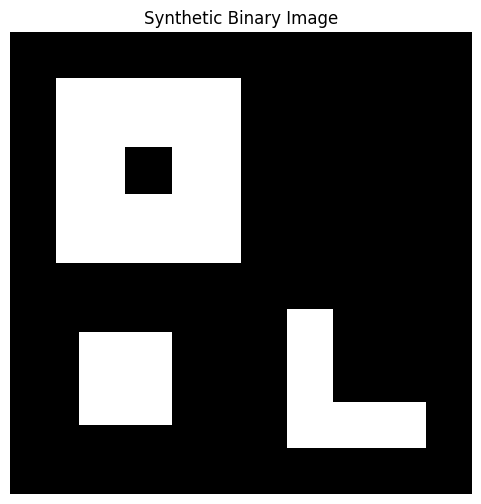

In [2]:
# Create a synthetic image with blocks, a hole, and separate objects
img = np.zeros((20, 20), dtype=np.uint8)

# Large square
img[2:10, 2:10] = 1

# Hole inside the large square
img[5:7, 5:7] = 0

# Small object
img[13:17, 3:7] = 1

# L-shape object
img[12:18, 12:14] = 1
img[16:18, 12:18] = 1

show(img, "Synthetic Binary Image")
plt.show()

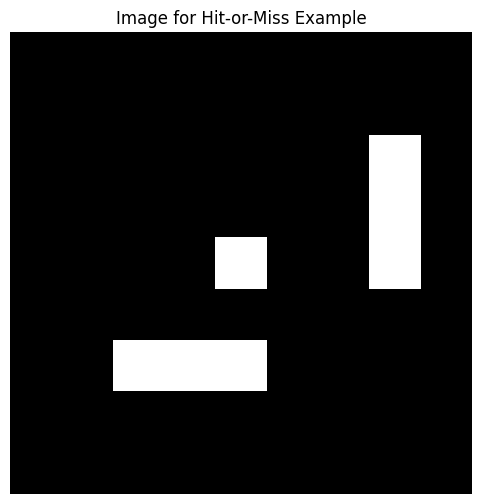

In [3]:
# Example image for hit-or-miss: detect isolated center pattern
hm_img = np.zeros((9, 9), dtype=np.uint8)
hm_img[4, 4] = 1
hm_img[2:5, 7] = 1
hm_img[6, 2:5] = 1

show(hm_img, "Image for Hit-or-Miss Example")
plt.show()

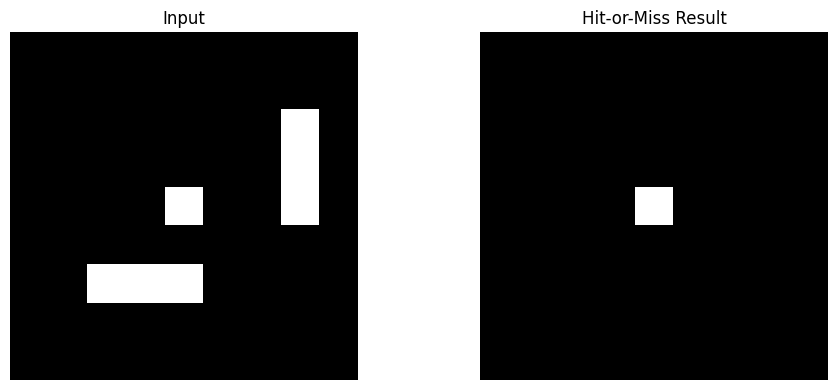

In [4]:
# Pattern: isolated single foreground pixel surrounded by background
B1 = np.array([[0,0,0],
               [0,1,0],
               [0,0,0]], dtype=bool)

# For the background mask, all 8 neighbors should be background
B2 = np.array([[1,1,1],
               [1,0,1],
               [1,1,1]], dtype=bool)

foreground_match = ndimage.binary_erosion(hm_img, structure=B1)
background_match = ndimage.binary_erosion(1 - hm_img, structure=B2)
hitmiss = foreground_match & background_match

show_pair(hm_img, hitmiss.astype(np.uint8), "Input", "Hit-or-Miss Result")
plt.show()

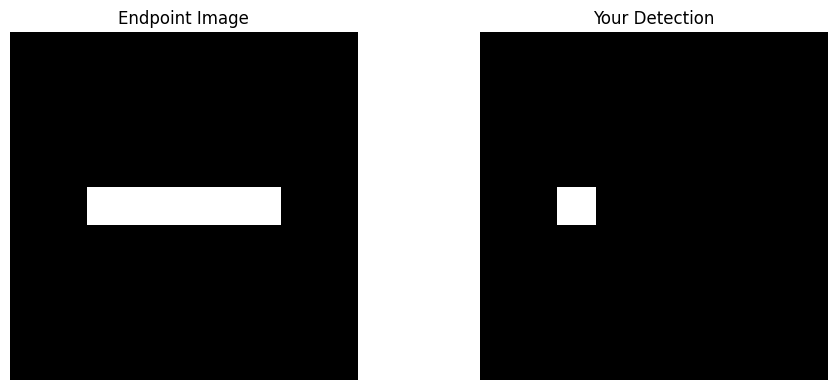

In [5]:
# Student task cell: define new B1 and B2 for endpoint detection

# Example image
endpoint_img = np.zeros((9, 9), dtype=np.uint8)
endpoint_img[4, 2:7] = 1

# TODO: replace these with your own endpoint pattern
B1_student = np.array([[0,0,0],
                       [0,1,1],
                       [0,0,0]], dtype=bool)

B2_student = np.array([[1,1,1],
                       [1,0,0],
                       [1,1,1]], dtype=bool)

fg = ndimage.binary_erosion(endpoint_img, structure=B1_student)
bg = ndimage.binary_erosion(1 - endpoint_img, structure=B2_student)
result_student = fg & bg

show_pair(endpoint_img, result_student.astype(np.uint8), "Endpoint Image", "Your Detection")
plt.show()

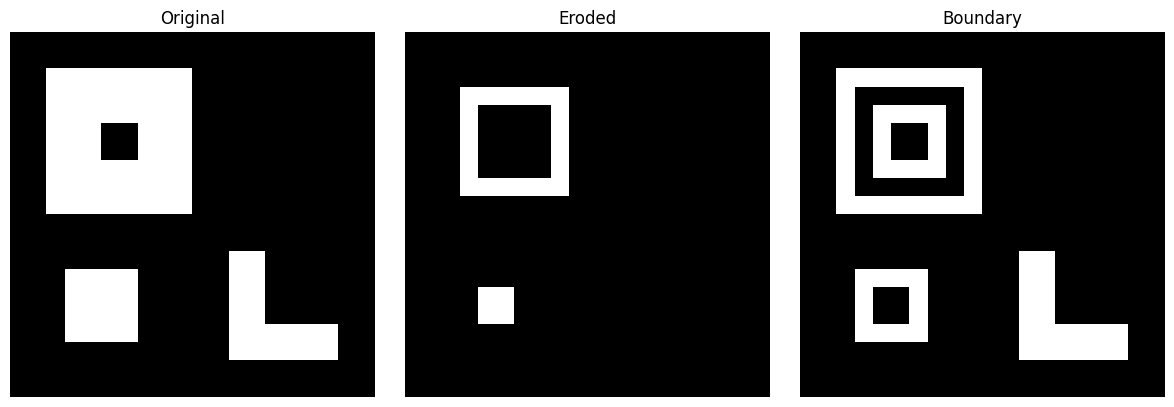

In [6]:
se = np.ones((3, 3), dtype=bool)
eroded = ndimage.binary_erosion(img, structure=se)
boundary = img & (~eroded)

show_triplet(img, eroded.astype(np.uint8), boundary.astype(np.uint8),
             "Original", "Eroded", "Boundary")
plt.show()

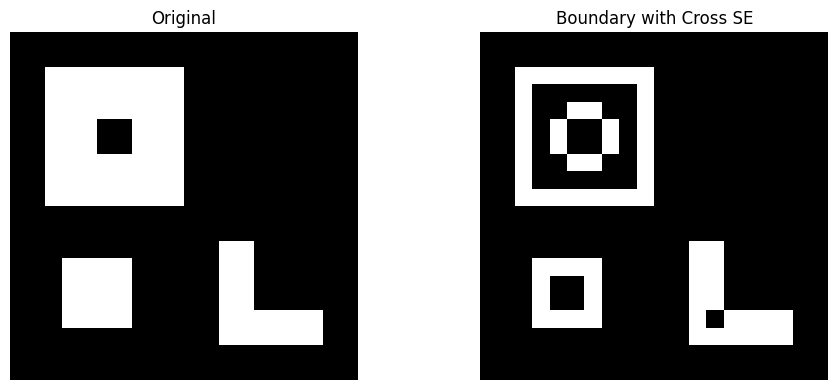

In [7]:
# Student task cell: experiment with different structuring elements
cross = np.array([[0,1,0],
                  [1,1,1],
                  [0,1,0]], dtype=bool)

eroded_cross = ndimage.binary_erosion(img, structure=cross)
boundary_cross = img & (~eroded_cross)

show_pair(img, boundary_cross.astype(np.uint8), "Original", "Boundary with Cross SE")
plt.show()

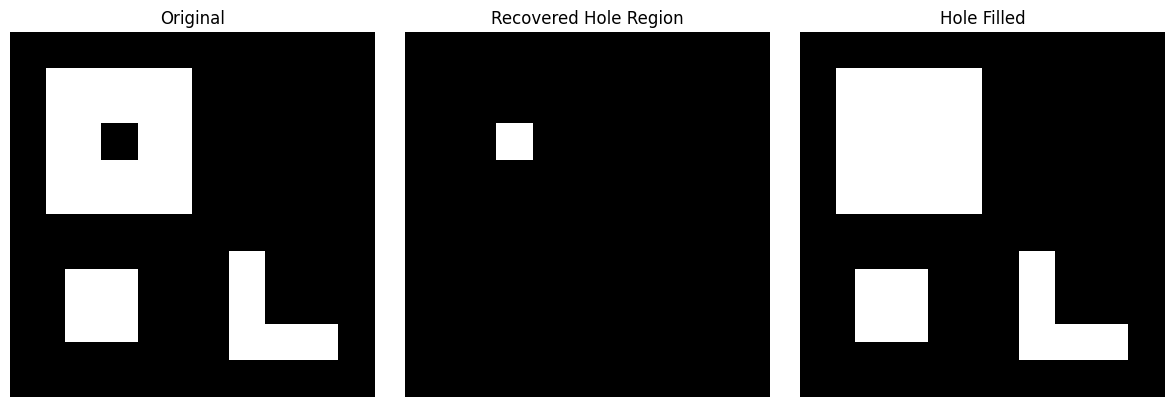

In [8]:
# Use a seed inside the hole of the large square
seed = np.zeros_like(img, dtype=bool)
seed[5, 5] = True  # seed inside hole

background = ~img.astype(bool)
structure = np.array([[0,1,0],
                      [1,1,1],
                      [0,1,0]], dtype=bool)

X_prev = seed.copy()

while True:
    X_next = ndimage.binary_dilation(X_prev, structure=structure) & background
    if np.array_equal(X_next, X_prev):
        break
    X_prev = X_next

filled_hole_region = X_prev
filled_img = img.astype(bool) | filled_hole_region

show_triplet(img, filled_hole_region.astype(np.uint8), filled_img.astype(np.uint8),
             "Original", "Recovered Hole Region", "Hole Filled")
plt.show()

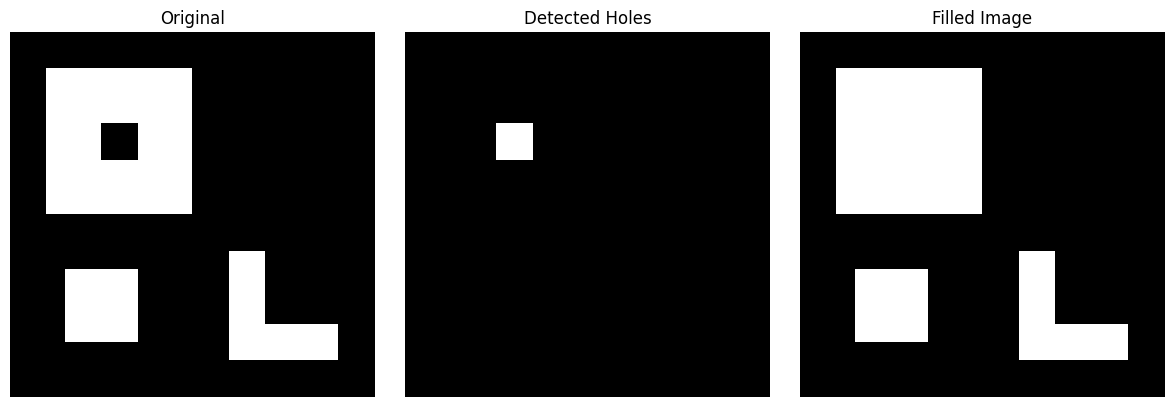

In [9]:
# Border-based hole filling
inv = 1 - img
seed_border = np.zeros_like(inv, dtype=bool)

seed_border[0, :] = inv[0, :]
seed_border[-1, :] = inv[-1, :]
seed_border[:, 0] = inv[:, 0]
seed_border[:, -1] = inv[:, -1]

outside = seed_border.copy()
while True:
    grown = ndimage.binary_dilation(outside, structure=structure) & inv.astype(bool)
    if np.array_equal(grown, outside):
        break
    outside = grown

holes = inv.astype(bool) & (~outside)
filled_by_border = img.astype(bool) | holes

show_triplet(img, holes.astype(np.uint8), filled_by_border.astype(np.uint8),
             "Original", "Detected Holes", "Filled Image")
plt.show()

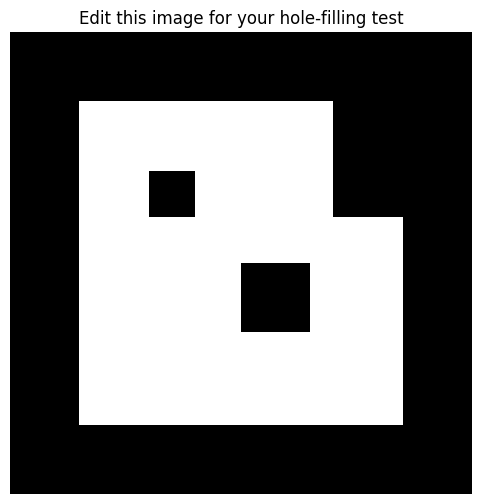

In [10]:
# Student task cell: build your own image here
student_holes = np.zeros((20, 20), dtype=np.uint8)
student_holes[3:17, 3:17] = 1
student_holes[6:8, 6:8] = 0
student_holes[10:13, 10:13] = 0
student_holes[3:8, 14:17] = 0  # border-connected gap because it touches outer object boundary

show(student_holes, "Edit this image for your hole-filling test")
plt.show()

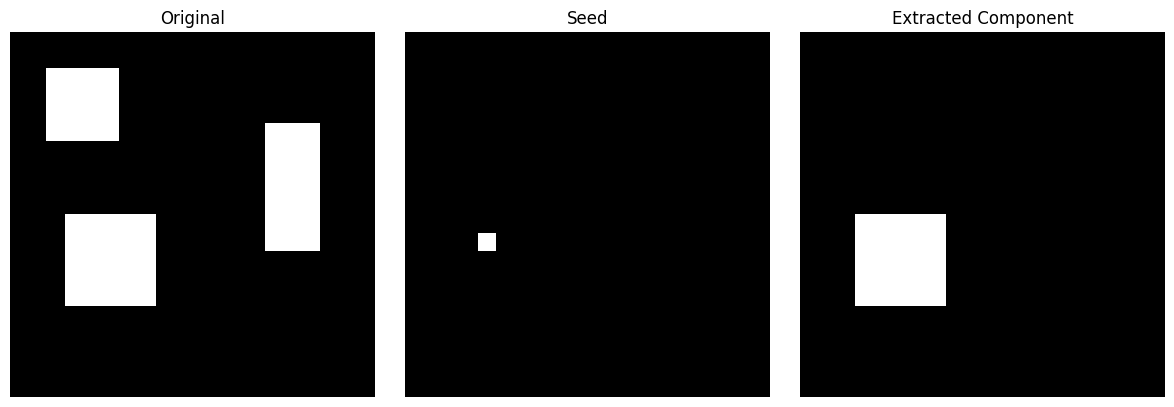

In [11]:
cc_img = np.zeros((20, 20), dtype=np.uint8)
cc_img[2:6, 2:6] = 1
cc_img[10:15, 3:8] = 1
cc_img[5:12, 14:17] = 1

seed_component = np.zeros_like(cc_img, dtype=bool)
seed_component[11, 4] = True  # inside second component

component = seed_component.copy()
while True:
    grown = ndimage.binary_dilation(component, structure=structure) & cc_img.astype(bool)
    if np.array_equal(grown, component):
        break
    component = grown

show_triplet(cc_img, seed_component.astype(np.uint8), component.astype(np.uint8),
             "Original", "Seed", "Extracted Component")
plt.show()

Number of connected components: 3
Labels present: [0 1 2 3]


/tmp/ipykernel_16123/1376084510.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("nipy_spectral", num_features + 1)


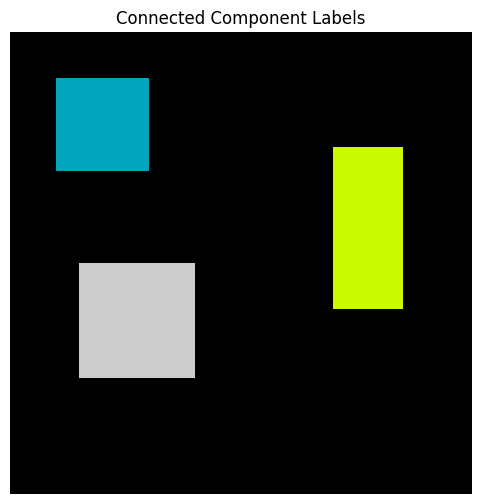

In [12]:
labeled, num_features = ndimage.label(cc_img)

print("Number of connected components:", num_features)
print("Labels present:", np.unique(labeled))

fig, ax = plt.subplots(figsize=(6, 6))
cmap = plt.cm.get_cmap("nipy_spectral", num_features + 1)
ax.imshow(labeled, cmap=cmap)
ax.set_title("Connected Component Labels")
ax.axis("off")
plt.show()

Areas of components: [16. 21. 25.]


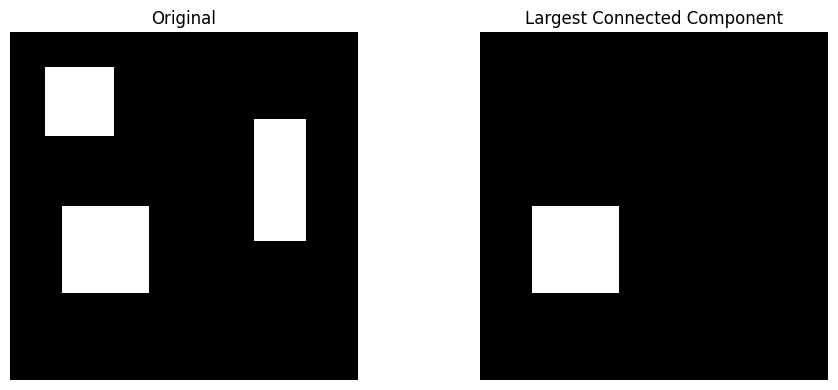

In [13]:
# Student task cell: measure areas and extract largest component
labeled_student, n_student = ndimage.label(cc_img)
areas = ndimage.sum(cc_img, labeled_student, index=range(1, n_student + 1))

print("Areas of components:", areas)

largest_label = np.argmax(areas) + 1
largest_component = (labeled_student == largest_label).astype(np.uint8)

show_pair(cc_img, largest_component, "Original", "Largest Connected Component")
plt.show()

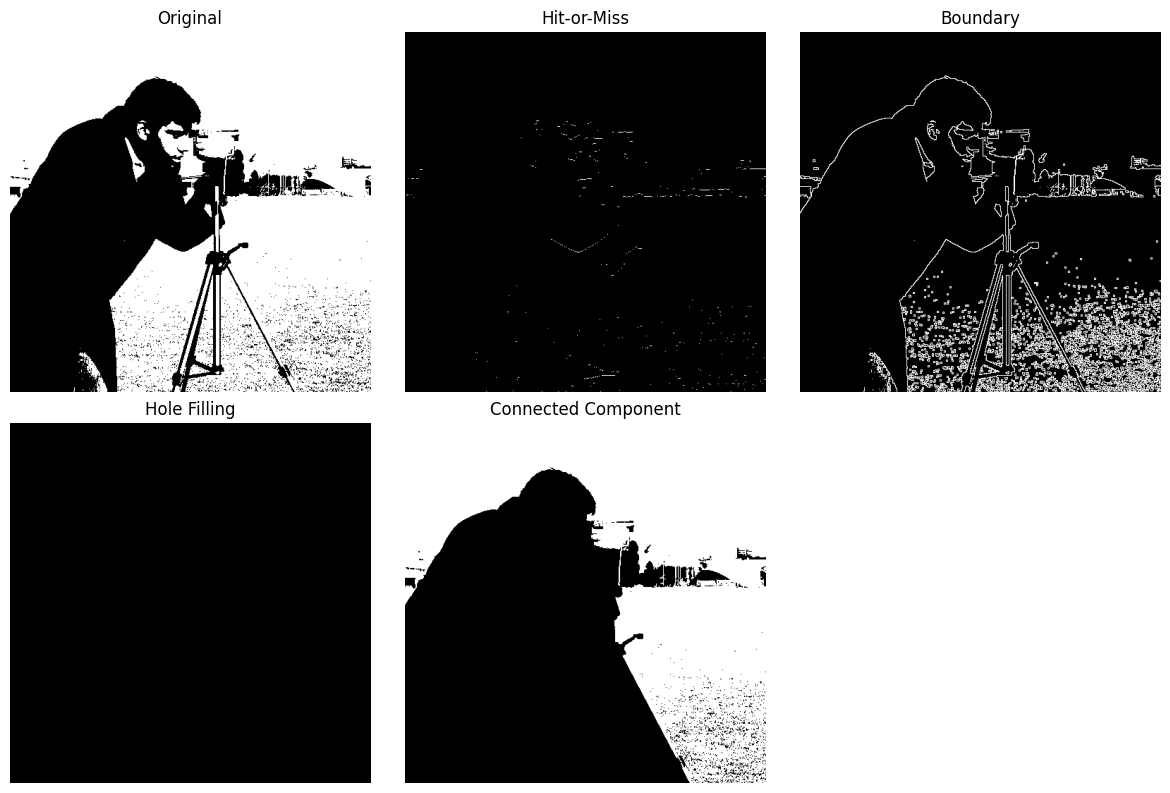

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("../data/images/camera.png", 0)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Hit-or-Miss
binary01 = (binary // 255).astype(np.uint8)
kernel = np.array([[-1,-1,-1],
                   [ 0, 1, 0],
                   [ 1, 1, 1]], dtype=np.int8)
hitmiss = cv2.morphologyEx(binary01, cv2.MORPH_HITMISS, kernel) * 255

# Boundary Extraction
se = np.ones((3,3), np.uint8)
boundary = cv2.subtract(binary, cv2.erode(binary, se))

# Hole Filling
mask = np.zeros((binary.shape[0]+2, binary.shape[1]+2), np.uint8)
flood = binary.copy()
cv2.floodFill(flood, mask, (0,0), 255)
holes = cv2.bitwise_not(flood)
filled = cv2.bitwise_or(binary, holes)

# Connected Components
num_labels, labels = cv2.connectedComponents(binary)
component = np.zeros_like(binary)
if num_labels > 1:
    component[labels == 1] = 255

# Display
plt.figure(figsize=(12,8))
plt.subplot(231), plt.imshow(binary, cmap='gray'), plt.title("Original"), plt.axis("off")
plt.subplot(232), plt.imshow(hitmiss, cmap='gray'), plt.title("Hit-or-Miss"), plt.axis("off")
plt.subplot(233), plt.imshow(boundary, cmap='gray'), plt.title("Boundary"), plt.axis("off")
plt.subplot(234), plt.imshow(filled, cmap='gray'), plt.title("Hole Filling"), plt.axis("off")
plt.subplot(235), plt.imshow(component, cmap='gray'), plt.title("Connected Component"), plt.axis("off")
plt.tight_layout()
plt.show()